In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [2]:
BASE_DIR = "../artifacts/Flickr8k"
IMAGES_DIR = os.path.join(BASE_DIR, "Images")

In [6]:
captions_df = pd.read_csv(os.path.join(BASE_DIR, "captions.txt"))

In [7]:
captions_df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [9]:
print(f"Total captions     : {len(captions_df)}")
print(f"Unique images      : {captions_df['image'].nunique()}")
print(f"Captions per image : {len(captions_df) / captions_df['image'].nunique()}")

Total captions     : 40455
Unique images      : 8091
Captions per image : 5.0


In [10]:
sample_image = captions_df.iloc[0]["image"]

In [12]:
sample_image

'1000268201_693b08cb0e.jpg'

In [13]:
sample_path = os.path.join(IMAGES_DIR, sample_image)

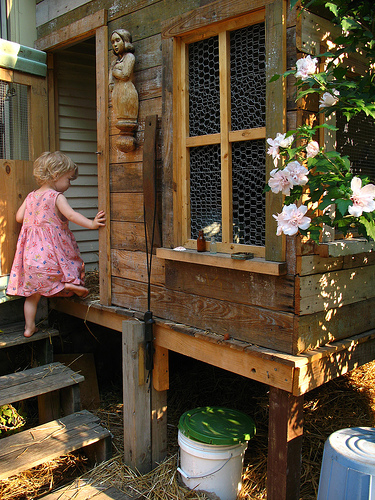

In [21]:
Image.open(sample_path)

In [22]:
# The 5 captions written for this image
captions_df[captions_df["image"] == sample_image]["caption"]

0    A child in a pink dress is climbing up a set o...
1                A girl going into a wooden building .
2     A little girl climbing into a wooden playhouse .
3    A little girl climbing the stairs to her playh...
4    A little girl in a pink dress going into a woo...
Name: caption, dtype: object

In [23]:
captions_per_image = captions_df.groupby("image")["caption"].size()
captions_per_image.describe()

count    8091.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
Name: caption, dtype: float64

## Caption length distribution

Knowing how long captions are helps us later choose `max_length` (the length we
pad every sequence to).

In [24]:
captions_df["caption_length"] = captions_df["caption"].apply(lambda c: len(c.split()))

In [27]:
# max len of caption : 38
captions_df["caption_length"].describe()

count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64

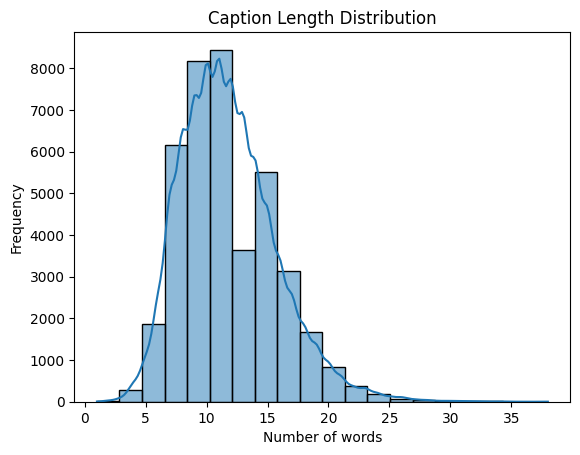

In [26]:
sns.histplot(captions_df["caption_length"], bins=20, kde=True)
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.title("Caption Length Distribution")
plt.show()